# Route Choice Model (MNL / Conditional Logit)

OTP 경로 피처 전체를 활용한 MNL 기반 경로 선택 모델.  
추정된 β 계수를 DTUMOS 시뮬레이션의 mode choice 파라미터로 매핑.

In [15]:
# Cell 1: 데이터 로드 및 탐색
import pandas as pd
import numpy as np
from pathlib import Path

DATA_DIR = Path('../data/training_set')

df = pd.read_parquet(DATA_DIR / 'route_choice_training.parquet')
print(f'집계 데이터: {len(df):,} rows, {df["od_pair"].nunique()} ODs')
print(f'Choice set size: min={df["choice_set_size"].min()}, max={df["choice_set_size"].max()}')
print(f'choice_prob 범위: [{df["choice_prob"].min():.4f}, {df["choice_prob"].max():.4f}]')
print(f'n_total 범위: [{df["n_total"].min()}, {df["n_total"].max()}]')
print()

# --- 피쳐 정의 ---
# 제외 사유:
#   total_duration: = in_vehicle_time + walk_time + wait_time (완벽 공선성)
#   walk_time: = access_time + egress_time + transfer_walk_time (완벽 공선성)
#   num_legs: = num_transfers + 1 (완벽 공선성, r=1.000)
#   walk_distance_km: walk time 3개와 공선 (SE 폭발)
#   transport_category: has_bus/has_train/has_gtx로 인코딩됨

TIME_RAW = ['in_vehicle_time', 'wait_time', 'access_time', 'egress_time', 'transfer_walk_time']
DIST_RAW = ['total_distance']

for col in TIME_RAW:
    df[col + '_min'] = df[col] / 60
for col in DIST_RAW:
    df[col + '_km'] = df[col] / 1000

MODEL_FEATURES = [
    'in_vehicle_time_min', 'wait_time_min',
    'access_time_min', 'egress_time_min', 'transfer_walk_time_min',
    'total_distance_km',
    'num_transfers',
    'fare',
    'has_bus', 'has_train', 'has_gtx',
]

FEATURE_LABELS = [
    'IVT (min)', 'Wait (min)',
    'Access walk (min)', 'Egress walk (min)', 'Transfer walk (min)',
    'Total dist (km)',
    'Transfers',
    'Fare (KRW)',
    'Has bus', 'Has train', 'Has GTX',
]

# 부호 제약: 경제이론상 음수여야 하는 피처
SIGN_CONSTRAINED_NEGATIVE = {
    'in_vehicle_time_min', 'wait_time_min',
    'access_time_min', 'egress_time_min', 'transfer_walk_time_min',
    'total_distance_km', 'num_transfers', 'fare',
}

# 분산 0인 피처 자동 제거
zero_var = [f for f in MODEL_FEATURES if df[f].nunique() <= 1]
if zero_var:
    labels_removed = [FEATURE_LABELS[MODEL_FEATURES.index(f)] for f in zero_var]
    print(f'분산 0 피처 자동 제거: {labels_removed}')
    FEATURE_LABELS = [l for f, l in zip(MODEL_FEATURES, FEATURE_LABELS) if f not in zero_var]
    MODEL_FEATURES = [f for f in MODEL_FEATURES if f not in zero_var]

print(f'모델 피처: {len(MODEL_FEATURES)}개')
print('제외: total_duration(공선), walk_time(공선), num_legs(공선), walk_distance(공선)')
print()

# 부호 제약 요약
print('=== 부호 제약 (L-BFGS-B bounds) ===')
for f, l in zip(MODEL_FEATURES, FEATURE_LABELS):
    if f in SIGN_CONSTRAINED_NEGATIVE:
        print(f'  {l:<22}: β ≤ 0 (constrained)')
    else:
        print(f'  {l:<22}: unconstrained')
print()

# 상관관계 확인
corr = df[MODEL_FEATURES].corr()
print('=== 높은 상관관계 (|r| > 0.8) ===')
for i in range(len(MODEL_FEATURES)):
    for j in range(i+1, len(MODEL_FEATURES)):
        r = corr.iloc[i, j]
        if abs(r) > 0.8:
            print(f'  {FEATURE_LABELS[i]} <-> {FEATURE_LABELS[j]}: r={r:.3f}')
print()
df[MODEL_FEATURES].describe().round(3)

집계 데이터: 2,232,801 rows, 597932 ODs
Choice set size: min=2, max=5
choice_prob 범위: [0.0000, 1.0000]
n_total 범위: [1, 13034]

모델 피처: 11개
제외: total_duration(공선), walk_time(공선), num_legs(공선), walk_distance(공선)

=== 부호 제약 (L-BFGS-B bounds) ===
  IVT (min)             : β ≤ 0 (constrained)
  Wait (min)            : β ≤ 0 (constrained)
  Access walk (min)     : β ≤ 0 (constrained)
  Egress walk (min)     : β ≤ 0 (constrained)
  Transfer walk (min)   : β ≤ 0 (constrained)
  Total dist (km)       : β ≤ 0 (constrained)
  Transfers             : β ≤ 0 (constrained)
  Fare (KRW)            : β ≤ 0 (constrained)
  Has bus               : unconstrained
  Has train             : unconstrained
  Has GTX               : unconstrained

=== 높은 상관관계 (|r| > 0.8) ===
  IVT (min) <-> Total dist (km): r=0.879
  Fare (KRW) <-> Has GTX: r=0.832



,in_vehicle_time_min,wait_time_min,access_time_min,egress_time_min,transfer_walk_time_min,total_distance_km,num_transfers,fare,has_bus,has_train,has_gtx
count,2232801.000,2232801.000,2232801.000,2232801.000,2232801.000,2232801.000,2232801.000,2232801.000,2232801.000,2232801.000,2232801.000
mean,23.123,3.560,1.571,1.661,1.096,11.602,0.708,1600.657,0.894,0.357,0.011
std,19.326,5.746,2.438,2.513,1.668,12.048,0.742,317.324,0.308,0.479,0.103
min,0.167,0.000,0.000,0.000,0.000,0.214,0.000,1500.000,0.000,0.000,0.000
25%,8.917,0.667,0.017,0.017,0.000,3.307,0.000,1500.000,1.000,0.000,0.000
50%,17.467,2.867,0.150,0.167,0.000,7.058,1.000,1500.000,1.000,0.000,0.000
75%,32.000,5.117,2.383,2.583,1.817,15.775,1.000,1550.000,1.000,1.000,0.000
max,298.783,1041.767,11.117,11.117,21.050,206.502,6.000,8700.000,1.000,1.000,1.000


In [16]:
# Cell 2: Train/Test Split (OD 단위, 수단별 층화)
from sklearn.model_selection import train_test_split

# OD별 대표 수단 = choice_prob 최대인 대안의 transport_category
od_dominant = df.loc[
    df.groupby('od_pair')['choice_prob'].idxmax(),
    ['od_pair', 'transport_category']
].set_index('od_pair')['transport_category']

# GTX 관련 카테고리는 합쳐서 층화 (개별로는 너무 적음)
def coarsen(cat):
    if 'gtx' in cat:
        return 'gtx_related'
    return cat

od_strat = od_dominant.map(coarsen)

od_list = od_strat.index.values
strat_labels = od_strat.values

train_ods_arr, test_ods_arr = train_test_split(
    od_list, test_size=0.2, random_state=42, stratify=strat_labels
)

train_od_set = set(train_ods_arr)
test_od_set = set(test_ods_arr)

train_df = df[df['od_pair'].isin(train_od_set)].copy()
test_df = df[df['od_pair'].isin(test_od_set)].copy()

train_ods = train_df['od_pair'].nunique()
test_ods = test_df['od_pair'].nunique()
train_trips = train_df.groupby('od_pair')['n_total'].first().sum()
test_trips = test_df.groupby('od_pair')['n_total'].first().sum()

print(f'Train: {len(train_df)} rows, {train_ods} ODs, {train_trips:,} effective trips')
print(f'Test:  {len(test_df)} rows, {test_ods} ODs, {test_trips:,} effective trips')
print(f'OD 겹침: {len(train_od_set & test_od_set)} (0이어야 함)')

# 층화 분포 확인
print('\n=== 층화 분포 확인 ===')
train_strat = od_strat.loc[train_ods_arr].value_counts(normalize=True).sort_index()
test_strat = od_strat.loc[test_ods_arr].value_counts(normalize=True).sort_index()
print(f'{"Category":<18} {"Train%":>8} {"Test%":>8}')
print('-' * 36)
for cat in train_strat.index:
    t_pct = train_strat.get(cat, 0) * 100
    te_pct = test_strat.get(cat, 0) * 100
    print(f'{cat:<18} {t_pct:>7.2f}% {te_pct:>7.2f}%')

Train: 1786488 rows, 478345 ODs, 30,999,753 effective trips
Test:  446313 rows, 119587 ODs, 7,662,606 effective trips
OD 겹침: 0 (0이어야 함)

=== 층화 분포 확인 ===
Category             Train%    Test%
------------------------------------
bus+train            19.47%   19.47%
bus_only             62.45%   62.45%
gtx_related           0.29%    0.29%
train_only           17.80%   17.80%


In [17]:
# Cell 3: MNL (Conditional Logit) 모델 구현 — 벡터화 + 부호 제약
# β ≤ 0 제약: 시간, 거리, 환승, 요금 (경제이론 기반)
# 모드 더미(has_bus, has_train, has_gtx)는 unconstrained
from scipy.optimize import minimize


def prepare_flat_data(data, features):
    """전체 데이터를 flat numpy array로 변환 (벡터 연산용)."""
    X_list, y_list, w_list, gid_list = [], [], [], []
    group_id = 0
    n_skipped = 0
    for od, grp in data.groupby('od_pair'):
        y = grp['choice_prob'].values.astype(np.float64)
        if abs(y.sum() - 1.0) > 0.01:
            n_skipped += 1
            continue
        X = grp[features].values.astype(np.float64)
        w = float(grp['n_total'].iloc[0])
        n = len(grp)
        X_list.append(X)
        y_list.append(y)
        w_list.append(np.full(n, w))
        gid_list.append(np.full(n, group_id, dtype=np.int64))
        group_id += 1

    flat = {
        'X': np.vstack(X_list),
        'y': np.concatenate(y_list),
        'w': np.concatenate(w_list),
        'gid': np.concatenate(gid_list),
        'n_groups': group_id,
    }
    if n_skipped:
        print(f'  choice_prob 합 ≠ 1.0 → {n_skipped} ODs 제외')
    return flat


def mnl_neg_ll(beta, flat):
    """Vectorized weighted negative log-likelihood."""
    X, y, w, gid, ng = flat['X'], flat['y'], flat['w'], flat['gid'], flat['n_groups']
    V = X @ beta
    V_max = np.full(ng, -np.inf)
    np.maximum.at(V_max, gid, V)
    V_shifted = V - V_max[gid]
    exp_V = np.exp(V_shifted)
    sum_exp = np.bincount(gid, weights=exp_V, minlength=ng)
    log_prob = V_shifted - np.log(sum_exp[gid])
    return -np.sum(w * y * log_prob)


def mnl_gradient(beta, flat):
    """Vectorized gradient."""
    X, y, w, gid, ng = flat['X'], flat['y'], flat['w'], flat['gid'], flat['n_groups']
    V = X @ beta
    V_max = np.full(ng, -np.inf)
    np.maximum.at(V_max, gid, V)
    V_shifted = V - V_max[gid]
    exp_V = np.exp(V_shifted)
    sum_exp = np.bincount(gid, weights=exp_V, minlength=ng)
    prob = exp_V / sum_exp[gid]
    return X.T @ (w * (prob - y))


train_flat = prepare_flat_data(train_df, MODEL_FEATURES)
print(f'유효 choice sets (train): {train_flat["n_groups"]:,}')
print(f'총 대안 수: {len(train_flat["y"]):,}')

# 부호 제약: β ≤ 0 for time/cost/distance/transfer features
bounds = []
for feat in MODEL_FEATURES:
    if feat in SIGN_CONSTRAINED_NEGATIVE:
        bounds.append((None, 0))   # β ≤ 0
    else:
        bounds.append((None, None))  # unconstrained

print(f'\n부호 제약 피처: {sum(1 for b in bounds if b[1] == 0)}개 (β ≤ 0)')
print(f'비제약 피처: {sum(1 for b in bounds if b[1] is None)}개')

beta0 = np.zeros(len(MODEL_FEATURES))

result = minimize(
    mnl_neg_ll, beta0, args=(train_flat,),
    jac=mnl_gradient, method='L-BFGS-B',
    bounds=bounds,
    options={'maxiter': 2000, 'ftol': 1e-12}
)

print(f'\n수렴: {result.success} ({result.message})')
print(f'반복: {result.nit}')
print(f'LL(β): {-result.fun:.4f}')

# 제약에 걸린 피처 확인
print('\n=== 제약 활성화 확인 ===')
for feat, label, b, bnd in zip(MODEL_FEATURES, FEATURE_LABELS, result.x, bounds):
    if bnd[1] == 0 and abs(b) < 1e-10:
        print(f'  {label:<22}: β = {b:.6f} (경계에 걸림 → 제약 활성)')

유효 choice sets (train): 478,345
총 대안 수: 1,786,488

부호 제약 피처: 8개 (β ≤ 0)
비제약 피처: 3개

수렴: True (CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH)
반복: 442
LL(β): -19556232.9395

=== 제약 활성화 확인 ===
  Wait (min)            : β = 0.000000 (경계에 걸림 → 제약 활성)
  Fare (KRW)            : β = 0.000000 (경계에 걸림 → 제약 활성)


In [18]:
# Cell 4: 모델 추정 결과
from scipy.optimize import approx_fprime

beta_hat = result.x
n_params = len(beta_hat)

# Hessian 근사 (벡터화 gradient에 유한차분)
eps = 1e-5
hessian = np.zeros((n_params, n_params))
for i in range(n_params):
    def grad_i(b, _i=i):
        return mnl_gradient(b, train_flat)[_i]
    hessian[i, :] = approx_fprime(beta_hat, grad_i, eps)

hessian = (hessian + hessian.T) / 2

# 표준오차 (경계에 걸린 피처는 SE 의미 없음 → N/A 표시)
try:
    cov_matrix = np.linalg.inv(hessian)
    std_errors = np.sqrt(np.abs(np.diag(cov_matrix)))
except np.linalg.LinAlgError:
    cov_matrix = np.linalg.pinv(hessian)
    std_errors = np.sqrt(np.abs(np.diag(cov_matrix)))

t_stats = beta_hat / np.where(std_errors > 0, std_errors, 1)

# LL(0): 균등 확률 모델
gid = train_flat['gid']
w = train_flat['w']
ng = train_flat['n_groups']
group_sizes = np.bincount(gid, minlength=ng)
w_per_group = np.bincount(gid, weights=w, minlength=ng) / group_sizes
ll_0 = -np.sum(w_per_group * np.log(group_sizes))
ll_beta = -result.fun
rho_sq = 1 - ll_beta / ll_0

train_trips = train_df.groupby('od_pair')['n_total'].first().sum()

print('=' * 75)
print('MNL (Conditional Logit) 추정 결과 — 부호 제약 모델')
print('=' * 75)
print(f'{"Feature":<22} {"β":>12} {"Std.Err":>12} {"t-stat":>10} {"Sig":>5} {"Bound":>8}')
print('-' * 75)
for i, (label, b, se, t) in enumerate(zip(FEATURE_LABELS, beta_hat, std_errors, t_stats)):
    sig = '***' if abs(t) > 2.576 else '**' if abs(t) > 1.960 else '*' if abs(t) > 1.645 else ''
    on_bound = MODEL_FEATURES[i] in SIGN_CONSTRAINED_NEGATIVE and abs(b) < 1e-10
    bound_str = '← bound' if on_bound else ''
    if on_bound:
        print(f'{label:<22} {b:>12.6f} {"N/A":>12} {"N/A":>10} {"":>5} {bound_str:>8}')
    else:
        print(f'{label:<22} {b:>12.6f} {se:>12.6f} {t:>10.3f} {sig:>5} {bound_str:>8}')
print('-' * 75)
print(f'LL(0):       {ll_0:.4f}')
print(f'LL(β):       {ll_beta:.4f}')
print(f'McFadden ρ²: {rho_sq:.4f}')
print(f'N (ODs):     {train_flat["n_groups"]:,}')
print(f'N (trips):   {train_trips:,} (weighted)')
print(f'K (params):  {n_params}')

# 부호 검증 — 전부 OK이어야 함
print('\n=== 부호 검증 ===')
all_ok = True
for feat, label, b in zip(MODEL_FEATURES, FEATURE_LABELS, beta_hat):
    if feat in SIGN_CONSTRAINED_NEGATIVE:
        ok = 'OK' if b <= 0 else 'FAIL'
        if ok != 'OK':
            all_ok = False
        print(f'  {label:<22}: β={b:>10.6f}  ≤ 0 → {ok}')
print(f'\n전체 부호: {"ALL CORRECT" if all_ok else "CHECK NEEDED"}')

MNL (Conditional Logit) 추정 결과 — 부호 제약 모델
Feature                           β      Std.Err     t-stat   Sig    Bound
---------------------------------------------------------------------------
IVT (min)                 -0.004686     0.000107    -43.669   ***         
Wait (min)                 0.000000          N/A        N/A        ← bound
Access walk (min)         -0.773812     0.000463  -1671.532   ***         
Egress walk (min)         -0.725478     0.000422  -1718.731   ***         
Transfer walk (min)       -0.117114     0.000539   -217.415   ***         
Total dist (km)           -0.098133     0.000370   -265.103   ***         
Transfers                 -2.777508     0.001525  -1821.230   ***         
Fare (KRW)                 0.000000          N/A        N/A        ← bound
Has bus                   -3.456894     0.002640  -1309.609   ***         
Has train                  1.480575     0.002814    526.215   ***         
Has GTX                    0.469160     0.024746     18.95

유효 choice sets (test): 119,587
테스트셋 평가 결과
Test LL(β):            -4867062.6201
Test LL(0):            -9224247.9367
Test McFadden ρ²:      0.4724
Top-1 Accuracy (FPR):  0.7034 (84118/119587)
Top-3 Accuracy:        0.9623 (115082/119587)
Cross-Entropy (per CS):40.6989
RMSE:                  0.2291
Train ρ²:              0.4746 (과적합 확인)

=== Top-3 by choice set size ===
  size=2: 100.0% (16271/16271) (≤3: trivially 100%)
  size=3: 100.0% (29846/29846) (≤3: trivially 100%)
  size=4:  95.8% (41297/43117) 
  size=5:  91.2% (27668/30353) 

=== 검증 기준 ===
  ρ² > 0.2:     PASS (0.4724)
  Top-1 > 60%:  PASS (70.3%)
  Top-3 > 85%:  PASS (96.2%)

=== 수단별 분담률 재현 ===
Category            Actual%    Pred%   Diff%p
--------------------------------------------
bus_only             53.39%   53.58%   +0.18
train_only           40.14%   40.03%   -0.12
bus+train             6.22%    6.15%   -0.07
train+gtx             0.19%    0.20%   +0.01
gtx_only              0.03%    0.03%   +0.00
bus+gtx               

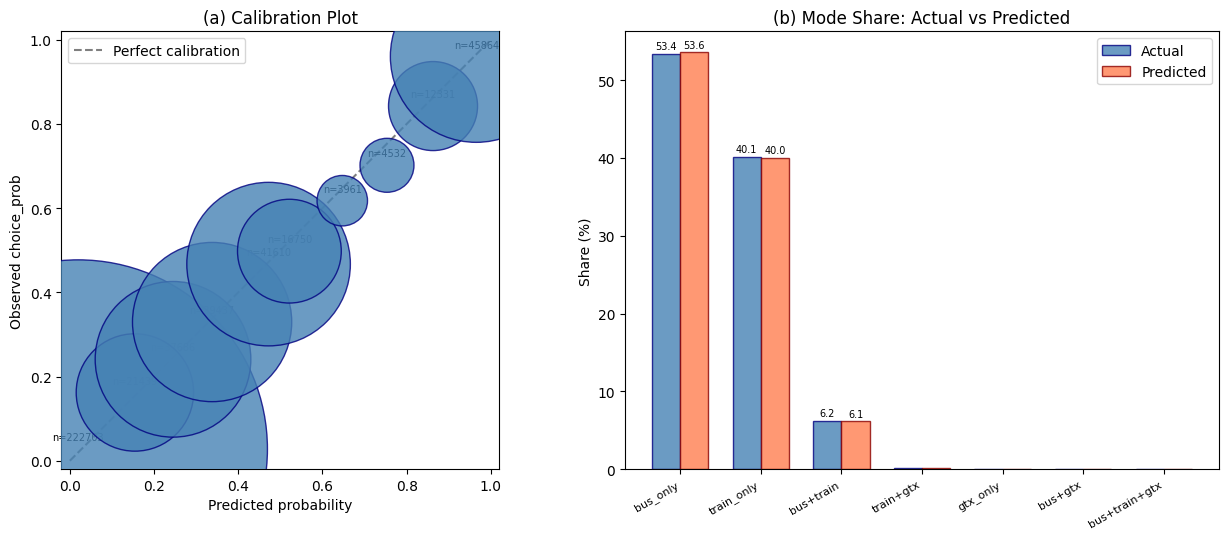

In [19]:
# Cell 5: 테스트셋 평가
import matplotlib.pyplot as plt

test_flat = prepare_flat_data(test_df, MODEL_FEATURES)
print(f'유효 choice sets (test): {test_flat["n_groups"]:,}')


def predict_probabilities(beta, flat):
    """벡터화 예측 확률."""
    X, y, w, gid, ng = flat['X'], flat['y'], flat['w'], flat['gid'], flat['n_groups']
    V = X @ beta
    V_max = np.full(ng, -np.inf)
    np.maximum.at(V_max, gid, V)
    V_shifted = V - V_max[gid]
    exp_V = np.exp(V_shifted)
    sum_exp = np.bincount(gid, weights=exp_V, minlength=ng)
    prob = exp_V / sum_exp[gid]
    return prob, y, gid, ng


# ── 기본 지표 ──
test_ll = -mnl_neg_ll(beta_hat, test_flat)

test_gid = test_flat['gid']
test_ng = test_flat['n_groups']
test_group_sizes = np.bincount(test_gid, minlength=test_ng)
test_w_per_group = np.bincount(test_gid, weights=test_flat['w'], minlength=test_ng) / test_group_sizes
test_ll_0 = -np.sum(test_w_per_group * np.log(test_group_sizes))
test_rho_sq = 1 - test_ll / test_ll_0

pred_prob, actual_y, gid_arr, ng = predict_probabilities(beta_hat, test_flat)

# ── 지표 1: Top-1 Accuracy (FPR) ──
top1_correct = 0
for g in range(ng):
    g_mask = gid_arr == g
    if np.argmax(pred_prob[g_mask]) == np.argmax(actual_y[g_mask]):
        top1_correct += 1
top1_acc = top1_correct / ng

# ── 지표 2: Top-3 Accuracy ──
top3_correct = 0
top3_correct_by_size = {}   # choice_set_size별 분석
group_sizes_arr = test_group_sizes  # 그룹별 대안 수

for g in range(ng):
    g_mask = gid_arr == g
    g_pred = pred_prob[g_mask]
    g_actual = actual_y[g_mask]
    k = min(3, len(g_pred))
    top_k_idx = np.argsort(g_pred)[-k:]  # 상위 k개 인덱스
    actual_best = np.argmax(g_actual)
    hit = actual_best in top_k_idx

    cs_size = len(g_pred)
    if cs_size not in top3_correct_by_size:
        top3_correct_by_size[cs_size] = [0, 0]
    top3_correct_by_size[cs_size][1] += 1
    if hit:
        top3_correct += 1
        top3_correct_by_size[cs_size][0] += 1

top3_acc = top3_correct / ng

# ── 지표 3: Cross-Entropy Loss ──
# CE = -Σ y * log(p), 이미 LL로 계산됨 → 가중 평균
total_weight = test_flat['w'].sum() / test_group_sizes[test_flat['gid']].mean()  # approx
ce_per_cs = -test_ll / ng           # choice set당 평균
ce_per_trip = -test_ll / test_w_per_group.sum()  # 통행당 평균 (가중)

# ── 지표 4: RMSE ──
rmse = np.sqrt(np.mean((pred_prob - actual_y) ** 2))

test_trips = test_df.groupby('od_pair')['n_total'].first().sum()

# ── 결과 출력 ──
print('=' * 60)
print('테스트셋 평가 결과')
print('=' * 60)
print(f'Test LL(β):            {test_ll:.4f}')
print(f'Test LL(0):            {test_ll_0:.4f}')
print(f'Test McFadden ρ²:      {test_rho_sq:.4f}')
print(f'Top-1 Accuracy (FPR):  {top1_acc:.4f} ({top1_correct}/{ng})')
print(f'Top-3 Accuracy:        {top3_acc:.4f} ({top3_correct}/{ng})')
print(f'Cross-Entropy (per CS):{ce_per_cs:.4f}')
print(f'RMSE:                  {rmse:.4f}')
print(f'Train ρ²:              {rho_sq:.4f} (과적합 확인)')

print('\n=== Top-3 by choice set size ===')
for cs_size in sorted(top3_correct_by_size):
    hit, total = top3_correct_by_size[cs_size]
    pct = hit / total * 100
    trivial = '(≤3: trivially 100%)' if cs_size <= 3 else ''
    print(f'  size={cs_size}: {pct:5.1f}% ({hit}/{total}) {trivial}')

print('\n=== 검증 기준 ===')
print(f'  ρ² > 0.2:     {"PASS" if test_rho_sq > 0.2 else "FAIL"} ({test_rho_sq:.4f})')
print(f'  Top-1 > 60%:  {"PASS" if top1_acc > 0.6 else "FAIL"} ({top1_acc*100:.1f}%)')
print(f'  Top-3 > 85%:  {"PASS" if top3_acc > 0.85 else "FAIL"} ({top3_acc*100:.1f}%)')

# ── 지표 5: 수단별 분담률 재현 ──
# test_df 행 순서와 test_flat 순서 동일하다는 가정 하에 transport_category 매칭
# prepare_flat_data에서 choice_prob 합 != 1인 OD 제외했으므로 유효 OD만 필터
valid_ods = set()
gid_counter = 0
for od, grp in test_df.groupby('od_pair'):
    y = grp['choice_prob'].values
    if abs(y.sum() - 1.0) > 0.01:
        continue
    valid_ods.add(od)
    gid_counter += 1

test_valid = test_df[test_df['od_pair'].isin(valid_ods)].copy()
test_valid['pred_prob'] = pred_prob
test_valid['actual_prob'] = actual_y

# 가중 분담률: Σ(n_total × prob) per category / Σ(n_total × prob) total
test_valid['w_actual'] = test_valid['n_total'] * test_valid['actual_prob']
test_valid['w_pred'] = test_valid['n_total'] * test_valid['pred_prob']

mode_actual = test_valid.groupby('transport_category')['w_actual'].sum()
mode_pred = test_valid.groupby('transport_category')['w_pred'].sum()

mode_actual_pct = (mode_actual / mode_actual.sum() * 100).sort_values(ascending=False)
mode_pred_pct = (mode_pred / mode_pred.sum() * 100).reindex(mode_actual_pct.index)

print('\n=== 수단별 분담률 재현 ===')
print(f'{"Category":<18} {"Actual%":>8} {"Pred%":>8} {"Diff%p":>8}')
print('-' * 44)
for cat in mode_actual_pct.index:
    a, p = mode_actual_pct[cat], mode_pred_pct[cat]
    print(f'{cat:<18} {a:>7.2f}% {p:>7.2f}% {p-a:>+7.2f}')

# ── 시각화: Calibration + Mode Share ──
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

# (a) Calibration Plot
ax = axes[0]
n_bins = 10
bin_edges = np.linspace(0, 1, n_bins + 1)
bin_means_pred, bin_means_actual, bin_counts = [], [], []

for i in range(n_bins):
    lo, hi = bin_edges[i], bin_edges[i + 1]
    mask = (pred_prob >= lo) & (pred_prob < hi) if i < n_bins - 1 else (pred_prob >= lo) & (pred_prob <= hi)
    if mask.sum() > 0:
        bin_means_pred.append(pred_prob[mask].mean())
        bin_means_actual.append(actual_y[mask].mean())
        bin_counts.append(int(mask.sum()))

ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Perfect calibration')
ax.scatter(bin_means_pred, bin_means_actual, s=[c / 3 for c in bin_counts],
           c='steelblue', edgecolors='navy', alpha=0.8, zorder=5)
for x, y, c in zip(bin_means_pred, bin_means_actual, bin_counts):
    ax.annotate(f'n={c}', (x, y), fontsize=7, ha='center', va='bottom',
                xytext=(0, 5), textcoords='offset points')
ax.set_xlabel('Predicted probability')
ax.set_ylabel('Observed choice_prob')
ax.set_title('(a) Calibration Plot')
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.02, 1.02)
ax.legend()
ax.set_aspect('equal')

# (b) Mode Share: Actual vs Predicted
ax = axes[1]
cats = mode_actual_pct.index.tolist()
x_pos = np.arange(len(cats))
w_bar = 0.35

bars1 = ax.bar(x_pos - w_bar/2, mode_actual_pct.values, w_bar, label='Actual', color='steelblue', edgecolor='navy', alpha=0.8)
bars2 = ax.bar(x_pos + w_bar/2, mode_pred_pct.values, w_bar, label='Predicted', color='coral', edgecolor='darkred', alpha=0.8)

for bar in bars1:
    h = bar.get_height()
    if h > 2:
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.3, f'{h:.1f}', ha='center', va='bottom', fontsize=7)
for bar in bars2:
    h = bar.get_height()
    if h > 2:
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.3, f'{h:.1f}', ha='center', va='bottom', fontsize=7)

ax.set_xticks(x_pos)
ax.set_xticklabels(cats, rotation=30, ha='right', fontsize=8)
ax.set_ylabel('Share (%)')
ax.set_title('(b) Mode Share: Actual vs Predicted')
ax.legend()

plt.tight_layout()
plt.show()

In [20]:
# Cell 6: DTUMOS 파라미터 매핑
beta_dict = dict(zip(MODEL_FEATURES, beta_hat))

dtumos_params = {
    'beta_time':     beta_dict['in_vehicle_time_min'],
    'beta_cost':     beta_dict['fare'],
    'beta_wait':     beta_dict['wait_time_min'],
    'beta_walk_access':  beta_dict['access_time_min'],
    'beta_walk_egress':  beta_dict['egress_time_min'],
    'beta_walk_transfer': beta_dict['transfer_walk_time_min'],
    'beta_transfer': beta_dict['num_transfers'],
}

walk_betas = [beta_dict['access_time_min'], beta_dict['egress_time_min'], beta_dict['transfer_walk_time_min']]
beta_walk_combined = np.mean(walk_betas)

defaults = {
    'beta_time': -0.05,
    'beta_cost': -0.0003,
    'beta_wait': -0.08,
    'beta_walk': -0.10,
    'beta_transfer': -0.30,
}

print('=' * 65)
print('DTUMOS ModeChoiceParams 매핑')
print('=' * 65)
print(f'{"DTUMOS Param":<25} {"Estimated":>12} {"Default":>12}')
print('-' * 65)
print(f'{"beta_time":<25} {dtumos_params["beta_time"]:>12.6f} {defaults["beta_time"]:>12.4f}')
print(f'{"beta_cost":<25} {dtumos_params["beta_cost"]:>12.6f} {defaults["beta_cost"]:>12.4f}')
print(f'{"beta_wait":<25} {dtumos_params["beta_wait"]:>12.6f} {defaults["beta_wait"]:>12.4f}')
print(f'{"beta_walk (combined)":<25} {beta_walk_combined:>12.6f} {defaults["beta_walk"]:>12.4f}')
print(f'{"  - access_walk":<25} {dtumos_params["beta_walk_access"]:>12.6f}')
print(f'{"  - egress_walk":<25} {dtumos_params["beta_walk_egress"]:>12.6f}')
print(f'{"  - transfer_walk":<25} {dtumos_params["beta_walk_transfer"]:>12.6f}')
print(f'{"beta_transfer":<25} {dtumos_params["beta_transfer"]:>12.6f} {defaults["beta_transfer"]:>12.4f}')

print('\n--- mode_choice.py 업데이트용 ---')
print(f'beta_time: float = {dtumos_params["beta_time"]:.6f}')
print(f'beta_cost: float = {dtumos_params["beta_cost"]:.6f}')
print(f'beta_wait: float = {dtumos_params["beta_wait"]:.6f}')
print(f'beta_walk: float = {beta_walk_combined:.6f}  # avg(access, egress, transfer)')
print(f'beta_transfer: float = {dtumos_params["beta_transfer"]:.6f}')

# 추가 피쳐 (직접 매핑 없음, 참고용)
print('\n--- 추가 추정 계수 (직접 DTUMOS 매핑 없음) ---')
extra = ['total_distance_km', 'has_bus', 'has_train', 'has_gtx']
for feat in extra:
    if feat in beta_dict:
        label = FEATURE_LABELS[MODEL_FEATURES.index(feat)]
        print(f'{label:<22}: β = {beta_dict[feat]:.6f}')

DTUMOS ModeChoiceParams 매핑
DTUMOS Param                 Estimated      Default
-----------------------------------------------------------------
beta_time                    -0.004686      -0.0500
beta_cost                     0.000000      -0.0003
beta_wait                     0.000000      -0.0800
beta_walk (combined)         -0.538801      -0.1000
  - access_walk              -0.773812
  - egress_walk              -0.725478
  - transfer_walk            -0.117114
beta_transfer                -2.777508      -0.3000

--- mode_choice.py 업데이트용 ---
beta_time: float = -0.004686
beta_cost: float = 0.000000
beta_wait: float = 0.000000
beta_walk: float = -0.538801  # avg(access, egress, transfer)
beta_transfer: float = -2.777508

--- 추가 추정 계수 (직접 DTUMOS 매핑 없음) ---
Total dist (km)       : β = -0.098133
Has bus               : β = -3.456894
Has train             : β = 1.480575
Has GTX               : β = 0.469160


In [21]:
# Cell 7: 저장
import json

train_ods = train_df['od_pair'].nunique()
test_ods = test_df['od_pair'].nunique()

coefficients = {
    'model': 'MNL (Conditional Logit)',
    'features': MODEL_FEATURES,
    'feature_labels': FEATURE_LABELS,
    'beta': {f: float(b) for f, b in zip(MODEL_FEATURES, beta_hat)},
    'std_errors': {f: float(se) for f, se in zip(MODEL_FEATURES, std_errors)},
    't_statistics': {f: float(t) for f, t in zip(MODEL_FEATURES, t_stats)},
    'train_stats': {
        'n_ods': train_ods,
        'n_trips_weighted': int(train_trips),
        'll_0': float(ll_0),
        'll_beta': float(ll_beta),
        'rho_squared': float(rho_sq),
    },
    'dtumos_mapping': {
        'beta_time': float(dtumos_params['beta_time']),
        'beta_cost': float(dtumos_params['beta_cost']),
        'beta_wait': float(dtumos_params['beta_wait']),
        'beta_walk': float(beta_walk_combined),
        'beta_walk_access': float(dtumos_params['beta_walk_access']),
        'beta_walk_egress': float(dtumos_params['beta_walk_egress']),
        'beta_walk_transfer': float(dtumos_params['beta_walk_transfer']),
        'beta_transfer': float(dtumos_params['beta_transfer']),
    },
}

coeff_path = DATA_DIR / 'mnl_coefficients.json'
with open(coeff_path, 'w', encoding='utf-8') as f:
    json.dump(coefficients, f, indent=2, ensure_ascii=False)
print(f'계수 저장: {coeff_path}')

evaluation = {
    'test_stats': {
        'n_ods': test_ods,
        'n_trips_weighted': int(test_trips),
        'll_0': float(test_ll_0),
        'll_beta': float(test_ll),
        'rho_squared': float(test_rho_sq),
        'top1_accuracy': float(top1_acc),
        'top1_count': f'{top1_correct}/{ng}',
        'top3_accuracy': float(top3_acc),
        'top3_count': f'{top3_correct}/{ng}',
        'cross_entropy_per_cs': float(ce_per_cs),
        'rmse': float(rmse),
    },
    'top3_by_choice_set_size': {
        str(k): {'hit': v[0], 'total': v[1], 'accuracy': v[0]/v[1]}
        for k, v in sorted(top3_correct_by_size.items())
    },
    'validation_checks': {
        'rho_sq_above_0.2': bool(test_rho_sq > 0.2),
        'top1_above_60pct': bool(top1_acc > 0.6),
        'top3_above_85pct': bool(top3_acc > 0.85),
        'no_overfitting': bool(test_rho_sq >= rho_sq * 0.8),
    },
    'mode_share': {
        cat: {'actual_pct': float(mode_actual_pct[cat]), 'pred_pct': float(mode_pred_pct[cat])}
        for cat in mode_actual_pct.index
    },
    'calibration': {
        'bin_pred_mean': [float(x) for x in bin_means_pred],
        'bin_actual_mean': [float(x) for x in bin_means_actual],
        'bin_counts': bin_counts,
    },
}

eval_path = DATA_DIR / 'model_evaluation.json'
with open(eval_path, 'w', encoding='utf-8') as f:
    json.dump(evaluation, f, indent=2, ensure_ascii=False)
print(f'평가 결과 저장: {eval_path}')

print('\nDone.')

계수 저장: ..\data\training_set\mnl_coefficients.json
평가 결과 저장: ..\data\training_set\model_evaluation.json

Done.
